In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [26]:
csv_path = "train.csv"
df = pd.read_csv(csv_path)
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index().sort_values("Order Date")
scaler = MinMaxScaler()
scaled = scaler.fit_transform(daily_sales["Sales"].values.reshape(-1,1))
window = 7
X, y = [], []
for i in range(len(scaled) - window):
    X.append(scaled[i:i+window])
    y.append(scaled[i+window])
X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [27]:
# --- Model Menggunakan SimpleRNN ---
tf.random.set_seed(42)

model = Sequential([
    # Layer 1: SimpleRNN dengan aktivasi 'relu'
    SimpleRNN(128, activation='relu', return_sequences=True, input_shape=(window,1)),
    Dropout(0.2), 
    
    # Layer 2: SimpleRNN dengan aktivasi 'relu'
    SimpleRNN(64, activation='relu', return_sequences=False),
    
    # Dense Layer 1 (Tambahan)
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    # Dense Layer 2 (Tambahan)
    Dense(32, activation='relu'),
    
    # Output Layer
    Dense(1)
])

# Menggunakan optimizer dengan Gradient Clipping (opsional, untuk stabilitas)
optimizer = tf.keras.optimizers.Adam(clipvalue=1.0)
model.compile(optimizer=optimizer, loss='mse')
print("Model Summary (SimpleRNN dengan ReLU dan Dense Tambahan):")
model.summary()


# --- Callbacks dan Pelatihan (Sama dengan kode Anda) ---
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6)
mc = ModelCheckpoint("best_simplernn.h5", monitor='val_loss', save_best_only=True)

Model Summary (SimpleRNN dengan ReLU dan Dense Tambahan):


c:\Users\Asus\Downloads\Tugas Kuliah Semester 5\AI\03_RNN_AI\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_9 (SimpleRNN)        │ (None, 7, 128)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,265 (137.75 KB)

 Trainable params: 35,265 (137.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    X_train, y_train,
    epochs=100, # Meningkatkan Epoch
    batch_size=32, # Mengubah Batch Size
    validation_data=(X_test, y_test),
    callbacks=[es, rlr, mc],
    verbose=1
)

Epoch 1/100
24/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0067 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 2/100
22/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0059 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 9/100
25/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0057 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061 - val_loss: 0.0081 - learning_rate: 5.0000e-04
Epoch 10/100
22/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0056 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 11/100
23/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 14/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0079 - learning_rate: 5.0000e-04
Epoch 15/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - val_loss: 0.0080 - learning_rate: 5.0000e-04
Epoch 16/100
24/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0061 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 17/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 18/100
23/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0055 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 19/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 20/100
25/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0056 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - val_loss: 0.0077 - learning_rate: 5.0000e-04
Epoch 21/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0078 - learning_rate: 5.0000e-04
Epoch 22/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0077 - learning_rate: 5.0000e-04
Epoch 23/100
24/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0055 

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - val_loss: 0.0075 - learning_rate: 2.5000e-04
Epoch 24/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 - val_loss: 0.0076 - learning_rate: 2.5000e-04
Epoch 25/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0076 - learning_rate: 2.5000e-04
Epoch 26/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0076 - learning_rate: 2.5000e-04
Epoch 27/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0077 - learning_rate: 2.5000e-04
Epoch 28/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0077 - learning_rate: 2.5000e-04
Epoch 29/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - val_loss: 0.0076 - learning_rate: 2.5000e-04
Epoch 30/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 0.0076 - learning_rate: 1.2500e-04
Epoch 31/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 0.0076 - learning_rate

In [29]:
# --- Evaluasi dan Visualisasi (Sama dengan kode Anda) ---
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [30]:
mae = mean_absolute_error(y_true, pred)
rmse = root_mean_squared_error(y_true, pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1701.2630
RMSE: 2439.2434


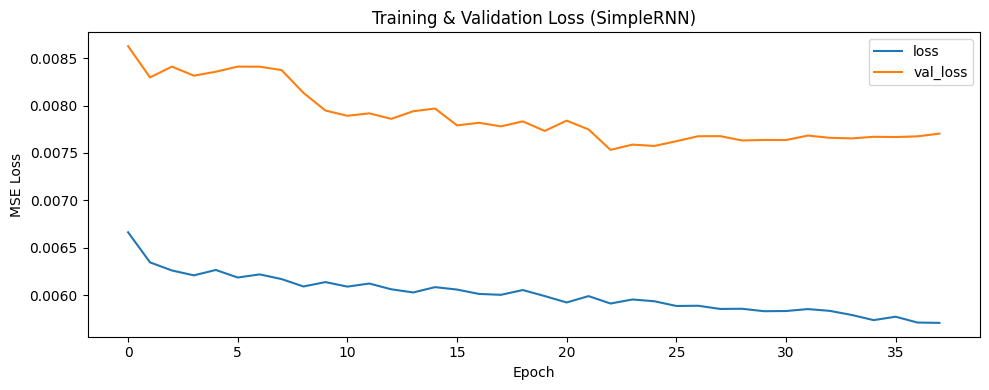

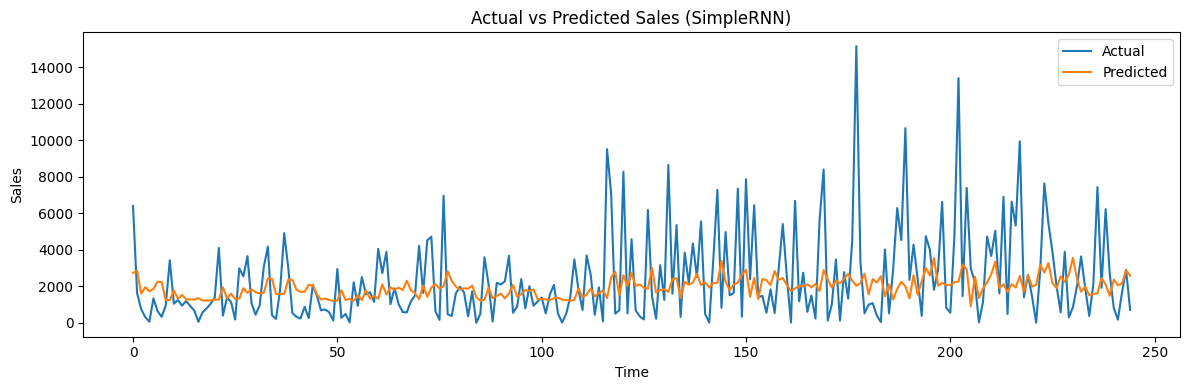

In [31]:
# Plot Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training & Validation Loss (SimpleRNN)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Aktual vs Prediksi
plt.figure(figsize=(12,4))
plt.plot(y_true, label='Actual')
plt.plot(pred, label='Predicted')
plt.title('Actual vs Predicted Sales (SimpleRNN)')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# # Opsional kalo mu simpan ke csv hasil prediksinya
# out_df = pd.DataFrame({
#     'Actual': y_true.flatten(),
#     'Predicted': pred.flatten()
# })
# out_df.to_csv("predictions.csv", index=False)
# print("Saved predictions.csv")